In [1]:
# import packages
import numpy as np
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
import pandas as pd
import coronagraph as cg
from scipy.interpolate import interp1d
from collections import namedtuple
import os
import glob
from matplotlib.lines import Line2D
import re
import matplotlib.colors as mcolors
from dataclasses import dataclass
from typing import Optional
from scipy.stats import binned_statistic_2d
import seaborn as sns
from pathlib import Path

/home/dylan/petitRADTRANS/pyRT/lib/python3.14/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/dylan/.config', but the default location, /home/dylan/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [2]:
plot_dir = r"/home/dylan/Research/W1243/plots"
os.makedirs(plot_dir, exist_ok=True)

In [3]:
# functions
Spectrum = namedtuple('Spectrum', ['wavelength', 'flux', 'error'])

@dataclass
class Model:
    flux: np.ndarray
    wavelength: Optional[np.ndarray] = None
    wavenumber: Optional[np.ndarray] = None

logg_dict = {
    '10':3.,
    '31':3.5,
    '100':4.,
    '316':4.5,
    '1000':5.,
    '3160':5.5
}

met_dict = {
    '0.32':'-0.5',
    '1.00':'0.0',
    '3.16':'0.5',
    '10.00':'1.0',
    '31.62':'1.5',
    '100.00':'2.0'
}

fsed_plot_dict = {
    'nc':"xkcd:faded orange",
    '1':'xkcd:cherry',
    '2':'xkcd:bright lavender',
    '3':"xkcd:robin's egg",
    '4':'xkcd:navy green',
    '8':'xkcd:royal blue'
}

logg_plot_dict = {
    3.:'X',
    3.5:'o',
    4.0:'s',
    4.5:'d',
    5.0:'P',
    5.5:'v'
}

met_plot_dict = {
    -0.5:.333,
    0.0:.666,
    +0.5:1
}

met_plot_dict_exorem = {
    -0.5:1/6,
    0.0:2/6,
    0.5:3/6,
    1.:4/6,
    1.5:5/6,
    2.:1
}

cmap = plt.get_cmap('viridis', 15)
color_dict_exorem = {
    round(0.10 + (i * 0.05), 2): mcolors.to_hex(cmap(i)) 
    for i in range(15)
}

def load_data(file_path):
    '''
    Takes in fits file and loads data into Spectrum namedtuple.
    '''
    with fits.open(file_path) as hdul:
        data = hdul[0].data
        
    return Spectrum(wavelength=data[0], flux=data[1], error=data[2])

def trim_data(spectrum, wavelength_min, wavelength_max):
    '''
    Chops off noisy ends of a spectrum, defined by 'wavelength_min' and 'wavelength_max'.
    '''
    mask = (spectrum.wavelength >= wavelength_min) & (spectrum.wavelength <= wavelength_max)

    return Spectrum(wavelength=spectrum.wavelength[mask], flux=spectrum.flux[mask], error=spectrum.error[mask])

def mask_water_bands(spectrum):
    '''
    Masks out water bands, 1.35–1.5 µm and 1.8–2.05 µm.
    '''
    wl = spectrum.wavelength
    
    mask = ~((wl >= 1.35) & (wl <= 1.5)) & ~((wl >= 1.8) & (wl <= 2.05))

    return Spectrum(wavelength=spectrum.wavelength[mask], flux=spectrum.flux[mask], error=spectrum.error[mask])
    
def init_model_df(directory, extension='*.txt'):
    '''
    Initialize Dataframe object for models in given directory.
    Does not save the wavelength or flux data, just filename.
    '''
    file_list = glob.glob(os.path.join(directory, extension))
    
    df = pd.DataFrame({'file_path': file_list})
    
    df['model_name'] = df['file_path'].apply(os.path.basename)
    
    return df
    
def load_model_spectrum(file_path, wavenumber=False, skip_rows=2):
    '''
    Loads model spectrum from file path into namedtuple.
    'skip_rows' for however many lines of preamble in spectra files.
    '''
    col_name = 'wavenumber' if wavenumber else 'wavelength'
    
    df = pd.read_csv(
        file_path, 
        sep=r'\s+', 
        skiprows=skip_rows, 
        header=None, 
        usecols=[0, 1],
        names=[col_name, 'flux']
    )
    
    return Model(**{col_name: df[col_name].values, 'flux': df['flux'].values})
    
def downbin_model(model, wavelength_min, wavelength_max, R = 100):
    '''
    Downbins model spectrum using coronagraph.
    '''
    wl_model = model.wavelength
    fl_model = model.flux
    
    wl, dwl = cg.noise_routines.construct_lam(wavelength_min, wavelength_max, R)
    fl_downbin = cg.downbin_spec(fl_model, wl_model, wl, dlam=dwl)

    model_downbin = Model(wavelength=wl, flux=fl_downbin)

    return model_downbin

def evaluate_model(model, spectrum):
    '''
    Returns chi2 and scaling factor alpha for given model and spectrum, following Mader et al. (2026).
    Will perform 1D interpolation.
    '''
    fl_model = model.flux
    wl_model = model.wavelength
    fl = spectrum.flux
    fl_err = spectrum.error
    wl = spectrum.wavelength

    itp = interp1d(wl_model, fl_model, kind='linear',bounds_error=False, fill_value="extrapolate")
    fl_model = itp(wl)
    
    w = 1.0 / (fl_err**2)

    alpha = np.sum(fl * fl_model * w)/np.sum(fl_model**2 * w)

    chi2 = np.sum(((fl - alpha * fl_model)**2) * w)

    return chi2, alpha

def parse_sonora_name(model_name):
    '''
    Updated to handle 'nc' without a preceding 'f'.
    '''
    pattern = (
        r"t(?P<teff>\d+)"                # 't' then digits
        r"g(?P<g>\d+)"                   # 'g' then digits
        r"(?P<fsed>f\d+|nc)?"            # Matches 'f8', 'f1', etc., OR 'nc'
        r"_m(?P<met>[+-]?\d+\.?\d*)"     # '_m' then metallicity
    )
    
    params = re.search(pattern, model_name)

    fsed_val = params.group('fsed')
    if fsed_val and fsed_val.startswith('f'):
        fsed_val = fsed_val[1:]

    return {
        'teff': float(params.group('teff')),
        'logg': logg_dict.get(params.group('g')),
        'fsed': fsed_val,
        'met':  float(params.group('met'))
    }

def set_plot_style(model_df):
    '''
    Sets plotting style for chi2 visualization.
    '''
    model_df = model_df.assign(
        plot_color=model_df['fsed'].map(fsed_plot_dict),
        plot_ms=model_df['logg'].map(logg_plot_dict),
        plot_alpha=model_df['met'].map(met_plot_dict)
    )
    return model_df

def parse_exorem_name(model_name):
    '''
    Will return a dictionary of parameters given the model file name.
    '''
    pattern = (
        r"YGP_(?P<teff>\d+)K_"          # 'YGP' then digits, ignores 'K_'
        r"logg(?P<logg>\d+\.?\d*)_"     # 'logg' then digits
        r"met(?P<met>\d+\.?\d*)_"       # 'met' then digits, needs to be converted to dex
        r"CO(?P<CO>\d+\.?\d*)"          # 'CO' then digits
    )

    params = re.search(pattern, model_name)

    return {
        'teff': float(params.group('teff')),
        'logg': float(params.group('logg')),
        'met': float(met_dict.get(params.group('met'))),
        'CO': float(params.group('CO'))
    }

def set_plot_style_exorem(model_df):
    '''
    Sets plotting style for chi2 visualization.
    '''
    model_df = model_df.assign(
        plot_color=model_df['CO'].map(color_dict_exorem),
        plot_ms=model_df['logg'].map(logg_plot_dict),
        plot_alpha=model_df['met'].map(met_plot_dict_exorem)
    )
    return model_df

In [4]:
# Load models
model_directory = r'/home/dylan/Models/'
sonora_db = rf'{model_directory}SonoraDiamondback/'
exorem = rf'{model_directory}EXO-REM/'
atmo_ceq = rf'{model_directory}ATMO2020/CEQ'
atmo_neq_strong = rf'{model_directory}ATMO2020/NEQ_strong'
atmo_neq_weak = rf'{model_directory}ATMO2020/NEQ_weak'

In [5]:
# Initialize data
W1243_file_path = r'/home/dylan/Research/W1243/spectra/CWISER_1243+6001_0.8prism_2020feb01.fits'
W1243_spectrum = load_data(W1243_file_path)
W1243_spectrum = trim_data(W1243_spectrum, .8, 2.5)
W1243_spectrum_masked = mask_water_bands(W1243_spectrum)

 ############################## Xspextool History ############################## [astropy.io.fits.card]
 ############################## Xcombspec History ############################## [astropy.io.fits.card]
 ############################### Xtellcor History ############################## [astropy.io.fits.card]


In [6]:
# Sonora Diamondback
# TODO: might be worth it to save downbinned models
sonora_results = "sonora_db_results.csv"

if Path(sonora_results).exists():
    sonora_db_df = pd.read_csv(sonora_results)

else:
    sonora_db_df = init_model_df(sonora_db, '*.spec')

    for index, row in sonora_db_df.iterrows():
        # Load model, then convert flux units
        model = load_model_spectrum(row['file_path'], skip_rows=3)
    
        model = downbin_model(model, .8, 2.5)
    
        flux_units = model.flux * u.W/u.m**2/u.m
        flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
        model.flux = flux_cgs.value
        # Now do model comparison
        chi2, alpha = evaluate_model(model, W1243_spectrum_masked)

        # Add results to model dataframe
        sonora_db_df.at[index, 'chi2'] = chi2
        sonora_db_df.at[index, 'alpha'] = alpha
    
    # Add params to dataframe
    params_list = [parse_sonora_name(name) for name in sonora_db_df['model_name']]
    params_df = pd.DataFrame(params_list, index=sonora_db_df.index)
    sonora_db_df = pd.concat([sonora_db_df, params_df], axis=1)
    
    # Add plotting settings for chi2 plot
    sonora_db_df = set_plot_style(sonora_db_df)

    # Save results
    sonora_db_df.to_csv(sonora_results, index=False)

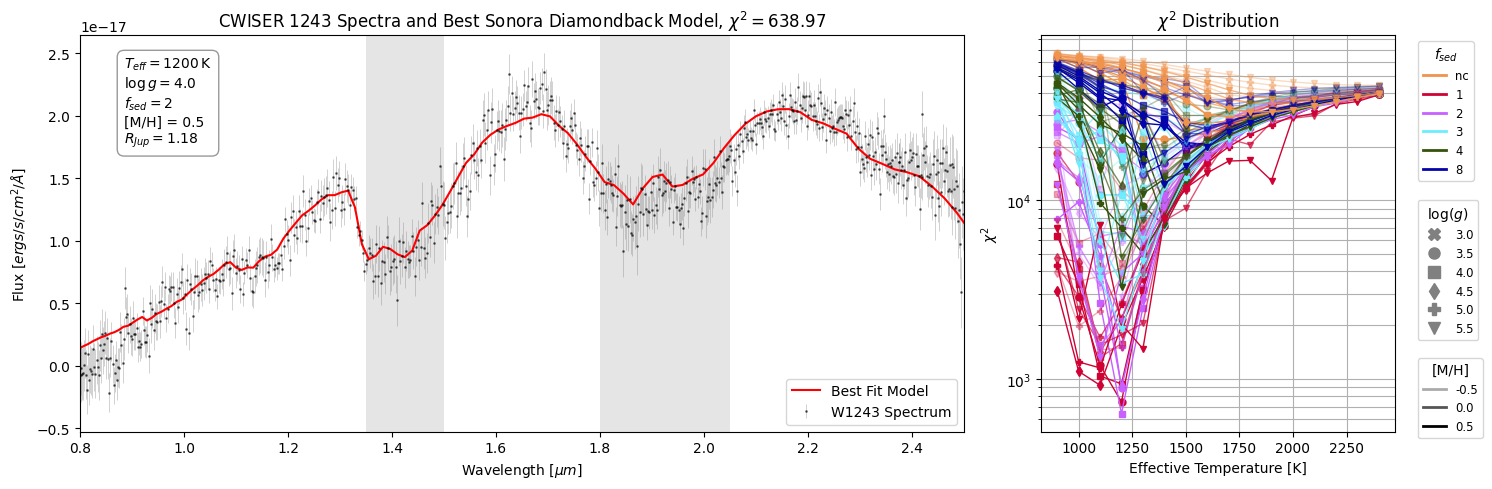

In [7]:
d = (44 * u.pc).to(u.R_jup)

best_idx = sonora_db_df['chi2'].idxmin()
best_row = sonora_db_df.loc[best_idx]
best_model_path = best_row['file_path']
best_alpha = best_row['alpha']
best_chi2 = best_row['chi2']
best_radius = (d * np.sqrt(best_alpha)).value

best_model = load_model_spectrum(best_model_path, skip_rows=3)
best_model = downbin_model(best_model, .8, 2.5)
flux_units = best_model.flux * u.W/u.m**2/u.m
flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
best_model.flux = flux_cgs.value

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.5,
    ecolor='gray',
    elinewidth=.5
)
water_bands = [
    (1.35, 1.5), 
    (1.8, 2.05)
]

# Loop through and fill the background on the spectrum plot (ax1)
for i, (start, end) in enumerate(water_bands):
    
    ax1.axvspan(
        start, end, 
        color='grey', 
        alpha=0.2, 
        lw=0, 
        zorder=0
    )

param_text = (
    rf"$T_{{eff}} = {best_row['teff']:.0f}\,$K" + "\n" +
    rf"$\log g = {best_row['logg']}$" + "\n" +
    rf"$f_{{sed}} = {best_row['fsed']}$" + "\n" +
    rf"[M/H] = {best_row['met']}" + "\n" +
    rf"$R_{{Jup}} = {best_radius:.2f}$"
)


ax1.text(
    0.05, 0.95, 
    param_text, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

ax1.plot(best_model.wavelength, best_model.flux*best_alpha, label='Best Fit Model', color='xkcd:fire engine red')
ax1.set_title(rf"CWISER 1243 Spectra and Best Sonora Diamondback Model, $\chi^2 = {best_chi2:.2f}$")
ax1.legend(loc='best')
ax1.set_xlabel(r"Wavelength [$\mu m$]")
ax1.set_ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
ax1.set_xlim(.8,2.5)

for (logg, fsed, met), group in sonora_db_df.groupby(['logg', 'fsed', 'met']):
    
    group = group.sort_values('teff')
    
    line_color = group['plot_color'].iloc[0]
    line_marker = group['plot_ms'].iloc[0]
    line_alpha = group['plot_alpha'].iloc[0]
    
    ax2.plot(
        group['teff'], 
        group['chi2'], 
        marker=line_marker,
        linestyle='-',          
        color=line_color, 
        alpha=line_alpha, 
        markersize=5,
        linewidth=1
    )


fsed_proxies = [
    Line2D([0], [0], color=color, lw=2, label=str(fsed)) 
    for fsed, color in fsed_plot_dict.items()
]

logg_proxies = [
    Line2D([0], [0], marker=marker, color='gray', label=str(logg), 
           ls='None', markersize=8) 
    for logg, marker in logg_plot_dict.items()
]

met_proxies = [
    Line2D([0], [0], color='k', alpha=alpha, lw=2, label=str(met)) 
    for met, alpha in met_plot_dict.items()
]

leg_fsed = ax2.legend(handles=fsed_proxies, title=r"$f_{sed}$", loc='upper left', 
                      bbox_to_anchor=(1.05, 1), frameon=True, fontsize='small')

leg_logg = ax2.legend(handles=logg_proxies, title=r"$\log(g)$", loc='upper left', 
                      bbox_to_anchor=(1.05, 0.5995), frameon=True, fontsize='small')

leg_met = ax2.legend(handles=met_proxies, title="[M/H]", loc='upper left', 
                     bbox_to_anchor=(1.05, 0.2), frameon=True, fontsize='small')

ax2.add_artist(leg_fsed)
ax2.add_artist(leg_logg)
ax2.set_yscale('log')
ax2.set_title(r'$\chi^2$ Distribution')
ax2.set_xlabel("Effective Temperature [K]")
ax2.set_ylabel(r"$\chi^2$")
ax2.grid(which='both')


plt.tight_layout()
plt.savefig(f"{plot_dir}/W1243_spectra_best_fit_sonora.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

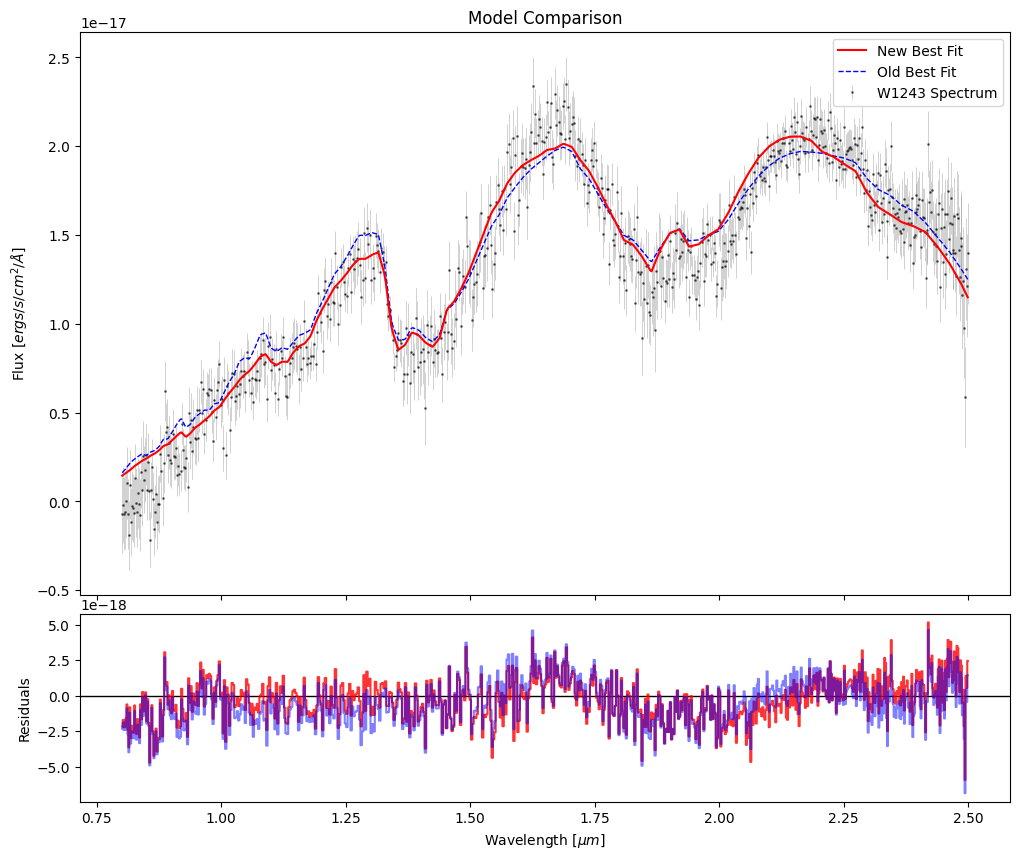

In [8]:
old_best_filepath = '/home/dylan/Models/SonoraDiamondback/t1200g31f1_m+0.5_co1.0.spec'

old_best_row = sonora_db_df[sonora_db_df['file_path'] == old_best_filepath].iloc[0]
old_best_alpha = old_best_row['alpha']

old_best_model = load_model_spectrum(old_best_filepath, skip_rows = 3)
old_best_model = downbin_model(old_best_model, .8, 2.5)
old_flux_units = old_best_model.flux * u.W/u.m**2/u.m
old_flux_cgs = old_flux_units.to(u.erg/u.s/u.cm**2/u.AA)
old_best_model.flux = old_flux_cgs.value

f_best = interp1d(best_model.wavelength, best_model.flux, kind='linear', fill_value="extrapolate")
f_old = interp1d(old_best_model.wavelength, old_best_model.flux, kind='linear', fill_value="extrapolate")

best_model_interp = f_best(W1243_spectrum.wavelength)
old_model_interp = f_old(W1243_spectrum.wavelength)

best_residuals = W1243_spectrum.flux - (best_model_interp * best_alpha)
old_residuals = W1243_spectrum.flux - (old_model_interp * old_best_alpha)

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax_spec = fig.add_subplot(gs[0])
ax_res  = fig.add_subplot(gs[1], sharex=ax_spec)

ax_spec.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.5,
    ecolor='gray',
    elinewidth=.5
)

ax_spec.plot(W1243_spectrum.wavelength, best_model_interp * best_alpha, 
             color='xkcd:fire engine red', lw=1.5, label='New Best Fit', zorder=10)

ax_spec.plot(W1243_spectrum.wavelength, old_model_interp * old_best_alpha, 
             color='blue', lw=1, ls='--', label='Old Best Fit', zorder=5)

ax_spec.set_ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
ax_spec.legend(loc='upper right')
plt.setp(ax_spec.get_xticklabels(), visible=False)

ax_res.axhline(0, color='k', lw=1)

ax_res.step(W1243_spectrum.wavelength, best_residuals, color='xkcd:fire engine red', where='mid', alpha=0.8)
ax_res.step(W1243_spectrum.wavelength, old_residuals, color='blue', where='mid', alpha=0.5)

ax_res.set_ylabel("Residuals")
ax_res.set_xlabel(r"Wavelength [$\mu m$]")
ax_spec.set_title("Model Comparison")
plt.savefig(f"{plot_dir}/W1243_spectra_model_comparison_sonora.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [9]:
# EXO-REM
exorem_results = "exorem_results.csv"

if Path(exorem_results).exists():
    exorem_df = pd.read_csv(exorem_results)

else:
    exorem_df = init_model_df(exorem, '*.dat')
    exorem_df = exorem_df[exorem_df['model_name'].str.contains('spectra', na=False)]
    exorem_df = exorem_df.reset_index(drop=True)
    
    for index, row in exorem_df.iterrows():
        model = load_model_spectrum(row['file_path'], wavenumber=True, skip_rows=2)

        model.wavelength = 10000.0 / model.wavenumber
        model.flux = model.flux * (model.wavenumber**2) * 100
        flux_units = model.flux * u.W/u.m**2/u.m
        flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
        model.flux = flux_cgs.value

        idx = np.argsort(model.wavelength)
        model.wavelength = model.wavelength[idx]
        model.flux = model.flux[idx]

        model = downbin_model(model, 0.8, 2.5)
        chi2, alpha = evaluate_model(model, W1243_spectrum_masked)

        exorem_df.at[index, 'chi2'] = chi2
        exorem_df.at[index, 'alpha'] = alpha

    # Add params to dataframe
    params_list = [parse_exorem_name(name) for name in exorem_df['model_name']]
    params_df = pd.DataFrame(params_list, index=exorem_df.index)
    exorem_df = pd.concat([exorem_df, params_df], axis=1)

    # Set plotting style
    exorem_df = set_plot_style_exorem(exorem_df)

    # Save results
    exorem_df.to_csv(exorem_results, index=False)

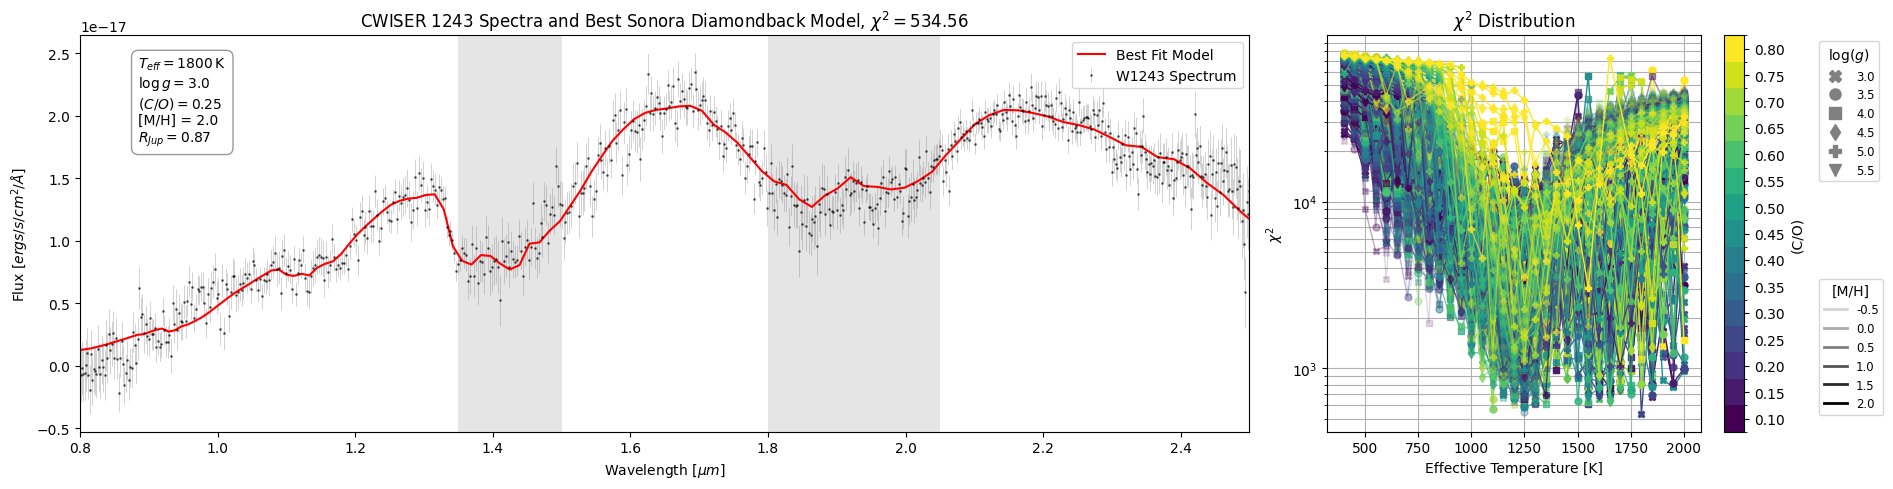

In [10]:
# TODO: Fix that god awful chi2 plot, should use the stuff Andrew sent
d = (44 * u.pc).to(u.R_jup)

best_idx = exorem_df['chi2'].idxmin()
best_row = exorem_df.loc[best_idx]
best_model_path = best_row['file_path']
best_alpha = best_row['alpha']
best_chi2 = best_row['chi2']
best_model_name = best_row['model_name']
best_model = load_model_spectrum(best_model_path, wavenumber = True, skip_rows=2)
best_radius = (d * np.sqrt(best_alpha)).value


best_model.wavelength = 10000.0 / best_model.wavenumber
best_model.flux = best_model.flux * (best_model.wavenumber**2) * 100
flux_units = best_model.flux * u.W/u.m**2/u.m
flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
best_model.flux = flux_cgs.value

idx = np.argsort(best_model.wavelength)
best_model.wavelength = best_model.wavelength[idx]
best_model.flux = best_model.flux[idx]

best_model = downbin_model(best_model, 0.8, 2.5)

fig = plt.figure(figsize=(19, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.5,
    ecolor='gray',
    elinewidth=.5
)
water_bands = [
    (1.35, 1.5), 
    (1.8, 2.05)
]

# Loop through and fill the background on the spectrum plot (ax1)
for i, (start, end) in enumerate(water_bands):
    
    ax1.axvspan(
        start, end, 
        color='grey', 
        alpha=0.2, 
        lw=0, 
        zorder=0
    )

param_text = (
    rf"$T_{{eff}} = {best_row['teff']:.0f}\,$K" + "\n" +
    rf"$\log g = {best_row['logg']}$" + "\n" +
    rf"$(C/O) = {best_row['CO']}$" + "\n" +
    rf"[M/H] = {best_row['met']}" + "\n" +
    rf"$R_{{Jup}} = {best_radius:.2f}$"
)


ax1.text(
    0.05, 0.95, 
    param_text, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)

ax1.plot(best_model.wavelength, best_model.flux*best_alpha, label='Best Fit Model', color='xkcd:fire engine red')
ax1.set_title(rf"CWISER 1243 Spectra and Best Sonora Diamondback Model, $\chi^2 = {best_chi2:.2f}$")
ax1.legend(loc='best')
ax1.set_xlabel(r"Wavelength [$\mu m$]")
ax1.set_ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
ax1.set_xlim(.8,2.5)

for (logg, CO, met), group in exorem_df.groupby(['logg', 'CO', 'met']):
    
    group = group.sort_values('teff')
    
    line_color = group['plot_color'].iloc[0]
    line_marker = group['plot_ms'].iloc[0]
    line_alpha = group['plot_alpha'].iloc[0]
    
    ax2.plot(
        group['teff'], 
        group['chi2'], 
        marker=line_marker,
        linestyle='-',          
        color=line_color, 
        alpha=line_alpha, 
        markersize=5,
        linewidth=1
    )


# fsed_proxies = [
#    Line2D([0], [0], color=color, lw=2, label=str(fsed)) 
#    for fsed, color in fsed_plot_dict.items()
# ]

logg_proxies = [
    Line2D([0], [0], marker=marker, color='gray', label=str(logg), 
           ls='None', markersize=8) 
    for logg, marker in logg_plot_dict.items()
]

met_proxies = [
    Line2D([0], [0], color='k', alpha=alpha, lw=2, label=str(met)) 
    for met, alpha in met_plot_dict_exorem.items()
]

# leg_fsed = ax2.legend(handles=fsed_proxies, title=r"$f_{sed}$", loc='upper left', 
#                       bbox_to_anchor=(1.05, 1), frameon=True, fontsize='small')

leg_logg = ax2.legend(handles=logg_proxies, title=r"$\log(g)$", loc='upper left', 
                      bbox_to_anchor=(1.3, 1), frameon=True, fontsize='small')

leg_met = ax2.legend(handles=met_proxies, title="[M/H]", loc='upper left', 
                     bbox_to_anchor=(1.3, 0.4), frameon=True, fontsize='small')

values = sorted(color_dict_exorem.keys())
colors = [color_dict_exorem[v] for v in values]

custom_cmap = mcolors.ListedColormap(colors)
boundaries = np.linspace(min(values) - 0.025, max(values) + 0.025, len(values) + 1)
norm = mcolors.BoundaryNorm(boundaries, custom_cmap.N)

sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2, ticks=values)
cbar.set_label('(C/O)')

#ax2.add_artist(leg_fsed)
ax2.add_artist(leg_logg)
ax2.set_yscale('log')
ax2.set_title(r'$\chi^2$ Distribution')
ax2.set_xlabel("Effective Temperature [K]")
ax2.set_ylabel(r"$\chi^2$")
ax2.grid(which='both')

plt.savefig(f"{plot_dir}/W1243_spectra_best_fit_exorem.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

/tmp/ipykernel_27798/2501338739.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


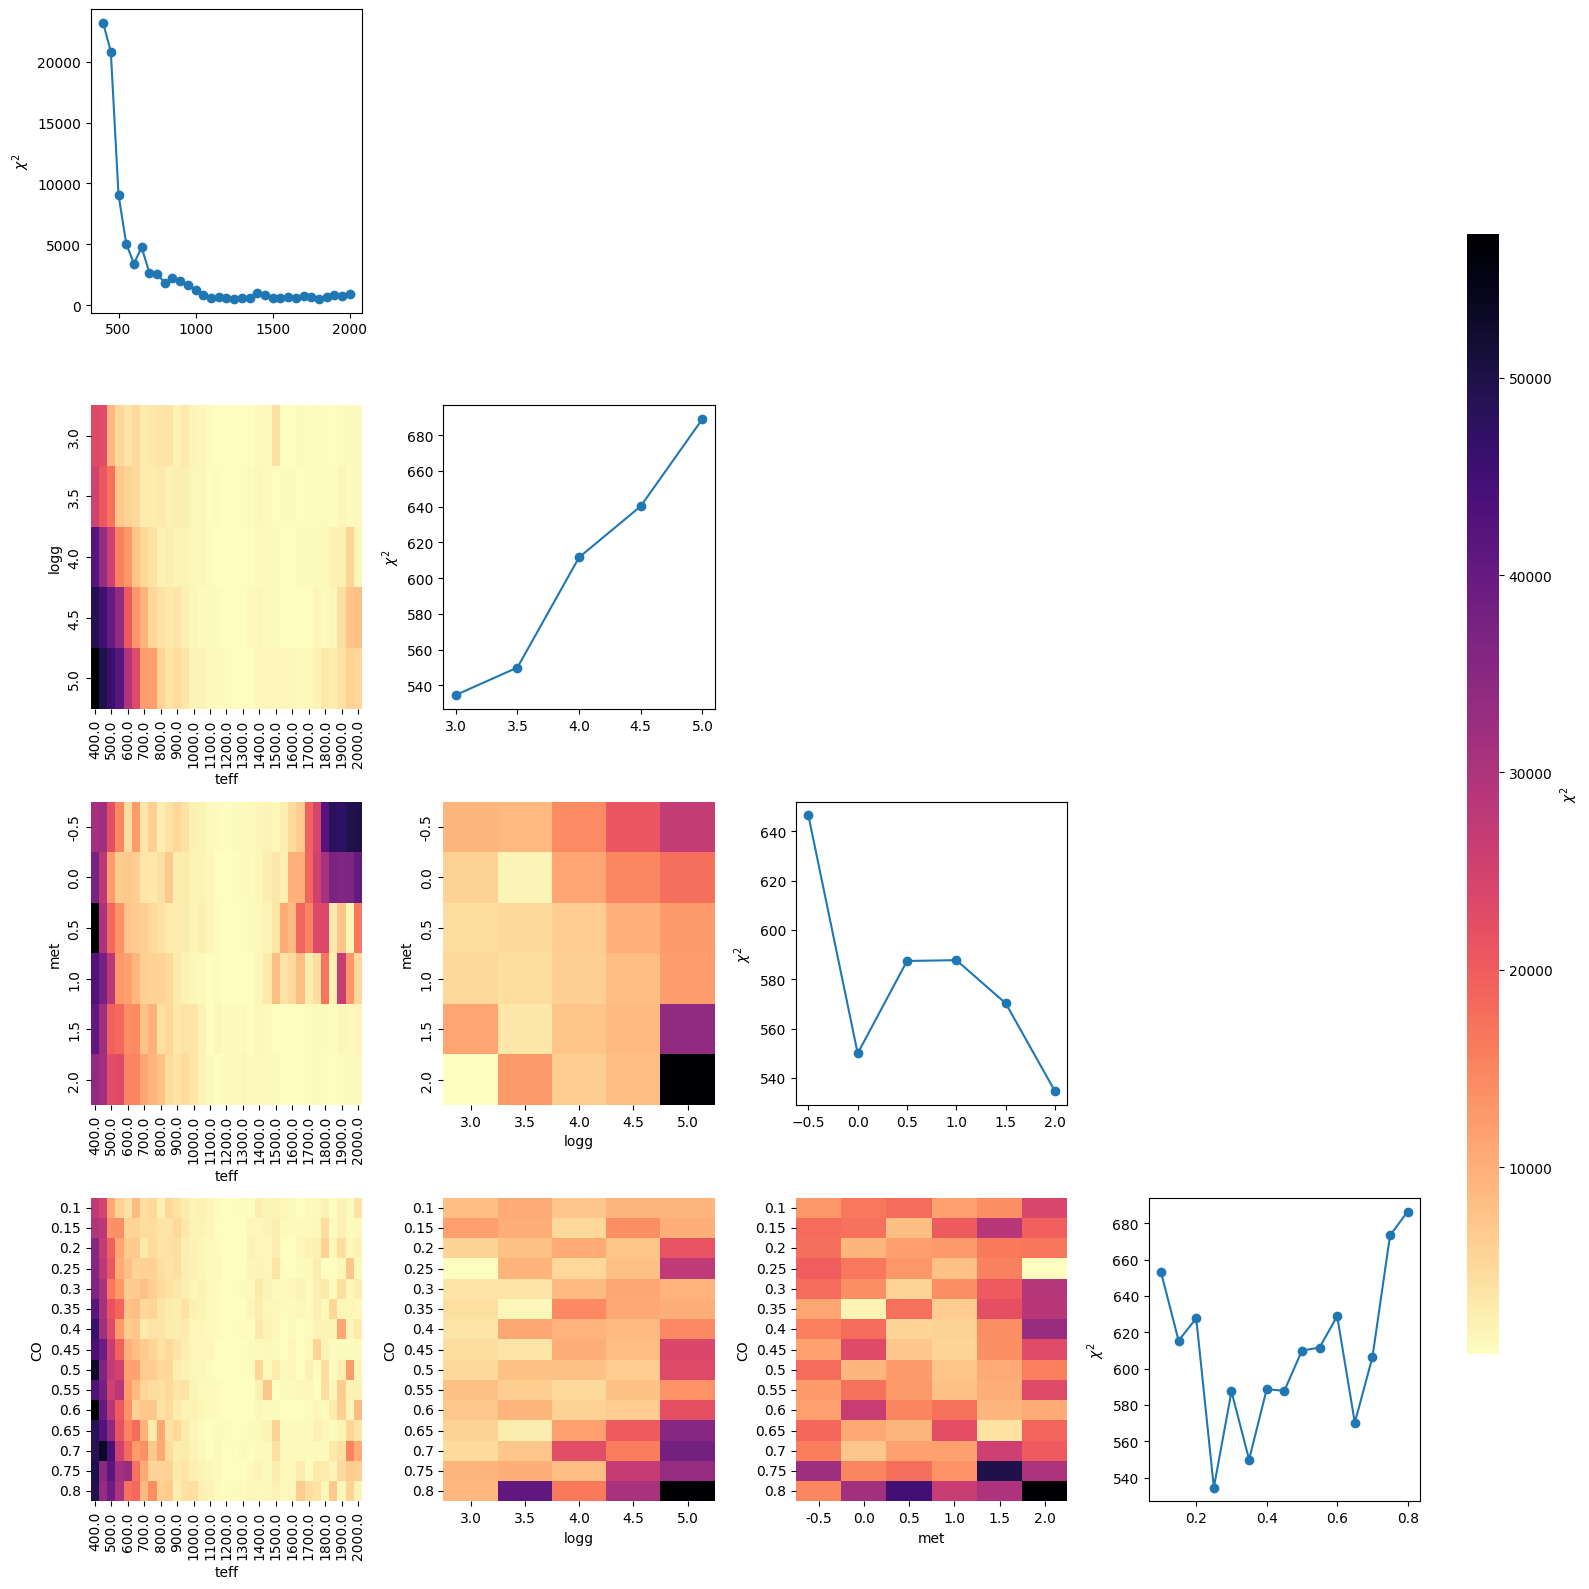

In [11]:
# inspired by Andrew's code so thank you Andrew
params = ['teff', 'logg', 'met', 'CO']
len_params = len(params)
fig, axes = plt.subplots(len_params, len_params, figsize=(16, 16))

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 

for i, p_row in enumerate(params):
    for j, p_col in enumerate(params):
        ax = axes[i, j]
        
        if i == j:
            min_chi2 = exorem_df.groupby(p_row)['chi2'].min()
            ax.plot(min_chi2.index, min_chi2.values, marker='o')
            ax.set_ylabel(r'$\chi^2$')
        elif i > j:

            surface = exorem_df.groupby([p_row, p_col])['chi2'].min().unstack()
            sns.heatmap(surface, ax=ax, cmap='magma_r', cbar=(i==1 and j==0), cbar_ax=cbar_ax, cbar_kws={'label': r'$\chi^2$'})
        else:
            ax.axis('off')
            
plt.tight_layout(rect=[0, 0, 0.9, 1]) 
plt.savefig(f"{plot_dir}/W1243_exorem_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

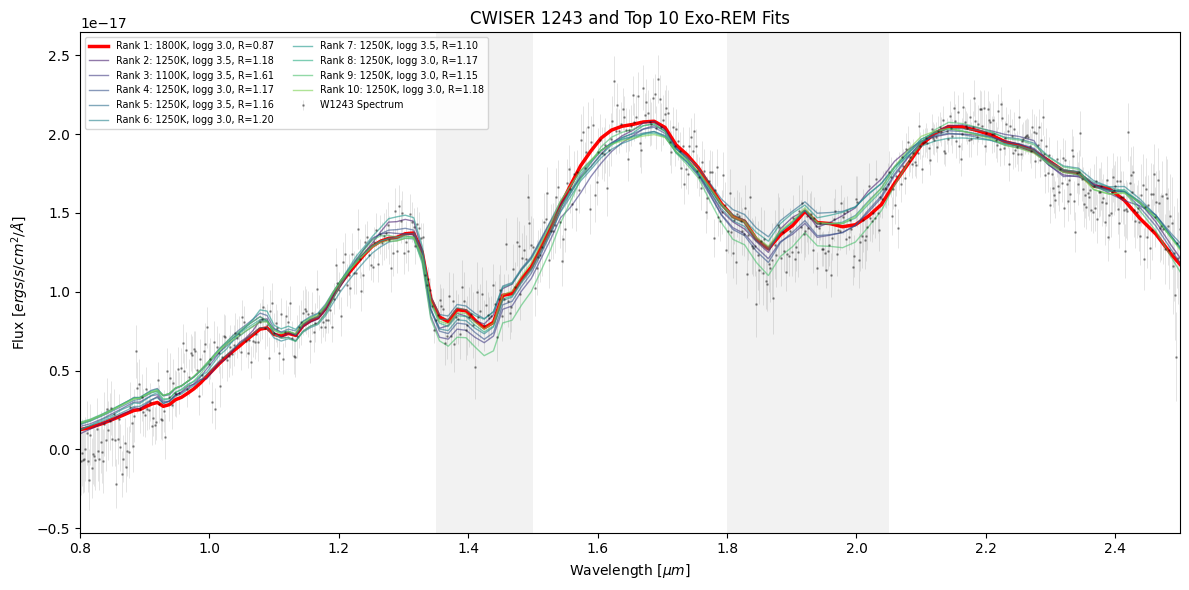

In [12]:
best_10_df = exorem_df.sort_values('chi2').head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.3,
    ecolor='gray',
    elinewidth=.5
)

water_bands = [(1.35, 1.5), (1.8, 2.05)]
for start, end in water_bands:
    ax1.axvspan(start, end, color='grey', alpha=0.1, lw=0, zorder=0)

colors = plt.cm.viridis(np.linspace(0, 0.8, 10))

for i, (idx, row) in enumerate(best_10_df.iterrows()):
    best_model_path = row['file_path']
    best_alpha = row['alpha']
    best_chi2 = row['chi2']
    
    best_model = load_model_spectrum(best_model_path, wavenumber=True, skip_rows=2)
    best_radius = (d * np.sqrt(best_alpha)).value
    
    best_model.wavelength = 10000.0 / best_model.wavenumber
    best_model.flux = best_model.flux * (best_model.wavenumber**2) * 100
    flux_units = best_model.flux * u.W/u.m**2/u.m
    flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    best_model.flux = flux_cgs.value

    idx = np.argsort(best_model.wavelength)
    best_model.wavelength = best_model.wavelength[idx]
    best_model.flux = best_model.flux[idx]


    best_model = downbin_model(best_model, 0.8, 2.5)

    label = f"Rank {i+1}: {row['teff']:.0f}K, logg {row['logg']}, R={best_radius:.2f}"
    line_color = 'r' if i == 0 else colors[i]
    line_width = 2.5 if i == 0 else 1.0
    line_alpha = 1.0 if i == 0 else 0.6
    
    ax1.plot(best_model.wavelength, best_model.flux * best_alpha, 
             label=label, color=line_color, lw=line_width, alpha=line_alpha)

ax1.set_title(rf"CWISER 1243 and Top 10 Exo-REM Fits")
ax1.set_xlabel(r"Wavelength [$\mu m$]")
ax1.set_ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
ax1.set_xlim(0.8, 2.5)
ax1.legend(loc='best', fontsize='x-small', ncol=2)

plt.tight_layout()
plt.savefig(f"{plot_dir}/W1243_spectra_top_10_exorem.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [13]:
# ATMO CEQ
atmo_ceq_results = "atmo_ceq_results.csv"

if Path(atmo_ceq_results).exists():
    atmo_ceq_df = pd.read_csv(atmo_ceq_results)

else:
    atmo_ceq_df = init_model_df(atmo_ceq, '*.txt')

    for index, row in atmo_ceq_df.iterrows():
        # Load model, then convert flux units
        model = load_model_spectrum(row['file_path'], skip_rows=2)
    
        model = downbin_model(model, .8, 2.5)
    
        flux_units = model.flux * u.W/u.m**2/u.micron
        flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
        model.flux = flux=flux_cgs.value

        # Now do model comparison
        chi2, alpha = evaluate_model(model, W1243_spectrum)
    
        # Add results to model dataframe
        atmo_ceq_df.at[index, 'chi2'] = chi2
        atmo_ceq_df.at[index, 'alpha'] = alpha

    # Save results
    atmo_ceq_df.to_csv(atmo_ceq_results, index=False)

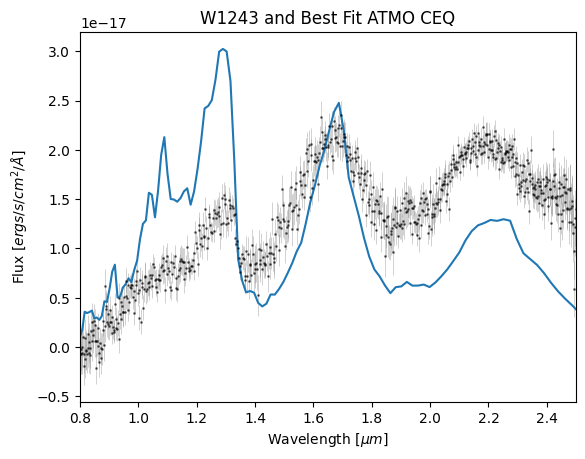

file_path     /home/dylan/Models/ATMO2020/CEQ/spec_T1600_lg2...
model_name                             spec_T1600_lg2.5_CEQ.txt
chi2                                               23891.519208
alpha                                                       0.0
Name: 171, dtype: object

In [14]:
best_idx = atmo_ceq_df['chi2'].idxmin()
best_row = atmo_ceq_df.loc[best_idx]
best_model_path = best_row['file_path']
best_alpha = best_row['alpha']
best_chi2 = best_row['chi2']

model = load_model_spectrum(best_model_path, skip_rows=2)

model = downbin_model(model, .8, 2.5)
    
flux_units = model.flux * u.W/u.m**2/u.micron
flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
model.flux = flux_cgs.value

plt.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.5,
    ecolor='gray',
    elinewidth=.5
)

plt.plot(model.wavelength, model.flux * best_alpha)
plt.title("W1243 and Best Fit ATMO CEQ")
plt.xlabel(r"Wavelength [$\mu m$]")
plt.ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
plt.xlim(0.8, 2.5)
plt.savefig(f"{plot_dir}/W1243_spectra_best_fit_atmo_ceq.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
best_row

In [15]:
# ATMO NEQ strong
atmo_neq_strong_results = "atmo_neq_strong_results.csv"

if Path(atmo_neq_strong_results).exists():
    atmo_neq_strong_df = pd.read_csv(atmo_neq_strong_results)

else:
    atmo_neq_strong_df = init_model_df(atmo_neq_strong, '*.txt')

    for index, row in atmo_neq_strong_df.iterrows():
        # Load model, then convert flux units
        model = load_model_spectrum(row['file_path'], skip_rows=2)
    
        model = downbin_model(model, .8, 2.5)
        
        flux_units = model.flux * u.W/u.m**2/u.micron
        flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
        model.flux = flux_cgs.value
    
        # Now do model comparison
        chi2, alpha = evaluate_model(model, W1243_spectrum_masked)

        # Add results to model dataframe
        atmo_neq_strong_df.at[index, 'chi2'] = chi2
        atmo_neq_strong_df.at[index, 'alpha'] = alpha

    # Save results
    atmo_neq_strong_df.to_csv(atmo_neq_strong_results, index=False)

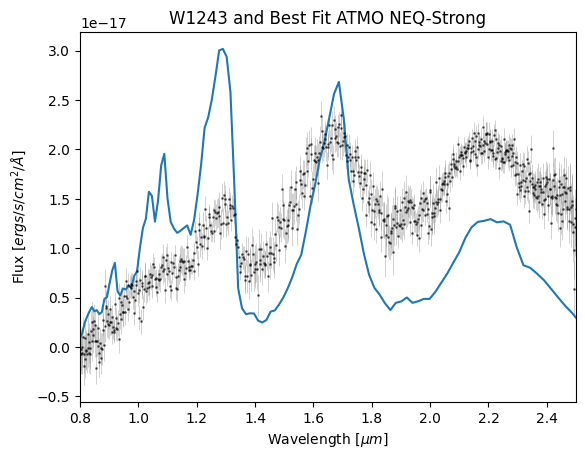

file_path     /home/dylan/Models/ATMO2020/NEQ_strong/spec_T1...
model_name                      spec_T1400_lg2.5_NEQ_strong.txt
chi2                                               19791.898445
alpha                                                       0.0
Name: 101, dtype: object

In [16]:
best_idx = atmo_neq_strong_df['chi2'].idxmin()
best_row = atmo_neq_strong_df.loc[best_idx]
best_model_path = best_row['file_path']
best_alpha = best_row['alpha']
best_chi2 = best_row['chi2']

model = load_model_spectrum(best_model_path, skip_rows=2)

model = downbin_model(model, .8, 2.5)
    
flux_units = model.flux * u.W/u.m**2/u.micron
flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
model.flux = flux_cgs.value

plt.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.5,
    ecolor='gray',
    elinewidth=.5
)
plt.plot(model.wavelength, model.flux * best_alpha)
plt.title("W1243 and Best Fit ATMO NEQ-Strong")
plt.xlabel(r"Wavelength [$\mu m$]")
plt.ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
plt.xlim(0.8, 2.5)
plt.savefig(f"{plot_dir}/W1243_spectra_best_fit_atmo_neq_strong.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
best_row

In [17]:
# ATMO NEQ weak
atmo_neq_weak_results = "atmo_neq_weak_results.csv"

if Path(atmo_neq_weak_results).exists():
    atmo_neq_weak_df = pd.read_csv(atmo_neq_weak_results)

else:
    atmo_neq_weak_df = init_model_df(atmo_neq_weak, '*.txt')

    for index, row in atmo_neq_weak_df.iterrows():
        # Load model, then convert flux units
        model = load_model_spectrum(row['file_path'], skip_rows=2)
    
        model = downbin_model(model, .8, 2.5)
        
        flux_units = model.flux * u.W/u.m**2/u.micron
        flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
        model.flux = flux_cgs.value
    
        # Now do model comparison
        chi2, alpha = evaluate_model(model, W1243_spectrum_masked)

        # Add results to model dataframe
        atmo_neq_weak_df.at[index, 'chi2'] = chi2
        atmo_neq_weak_df.at[index, 'alpha'] = alpha

    # Save results
    atmo_neq_weak_df.to_csv(atmo_neq_weak_results, index=False)

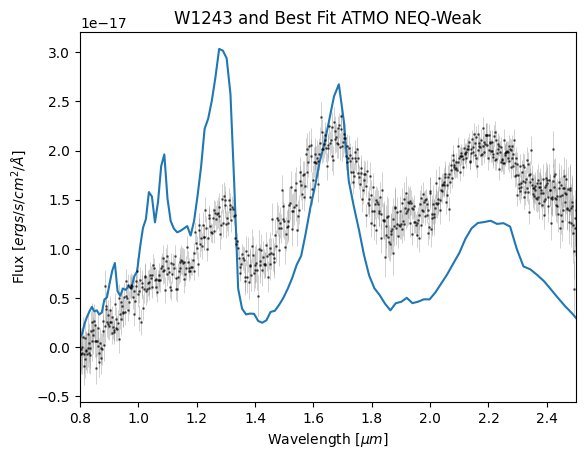

file_path     /home/dylan/Models/ATMO2020/NEQ_weak/spec_T140...
model_name                        spec_T1400_lg2.5_NEQ_weak.txt
chi2                                               19976.362323
alpha                                                       0.0
Name: 51, dtype: object

In [18]:
best_idx = atmo_neq_weak_df['chi2'].idxmin()
best_row = atmo_neq_weak_df.loc[best_idx]
best_model_path = best_row['file_path']
best_alpha = best_row['alpha']
best_chi2 = best_row['chi2']

model = load_model_spectrum(best_model_path, skip_rows=2)

model = downbin_model(model, .8, 2.5)
    
flux_units = model.flux * u.W/u.m**2/u.micron
flux_cgs= flux_units.to(u.erg/u.s/u.cm**2/u.AA)
    
model.flux = flux_cgs.value

plt.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.5,
    ecolor='gray',
    elinewidth=.5
)
plt.plot(model.wavelength, model.flux * best_alpha)
plt.title("W1243 and Best Fit ATMO NEQ-Weak")
plt.xlabel(r"Wavelength [$\mu m$]")
plt.ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
plt.xlim(0.8, 2.5)
plt.savefig(f"{plot_dir}/W1243_spectra_best_fit_atmo_neq_weak.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
best_row

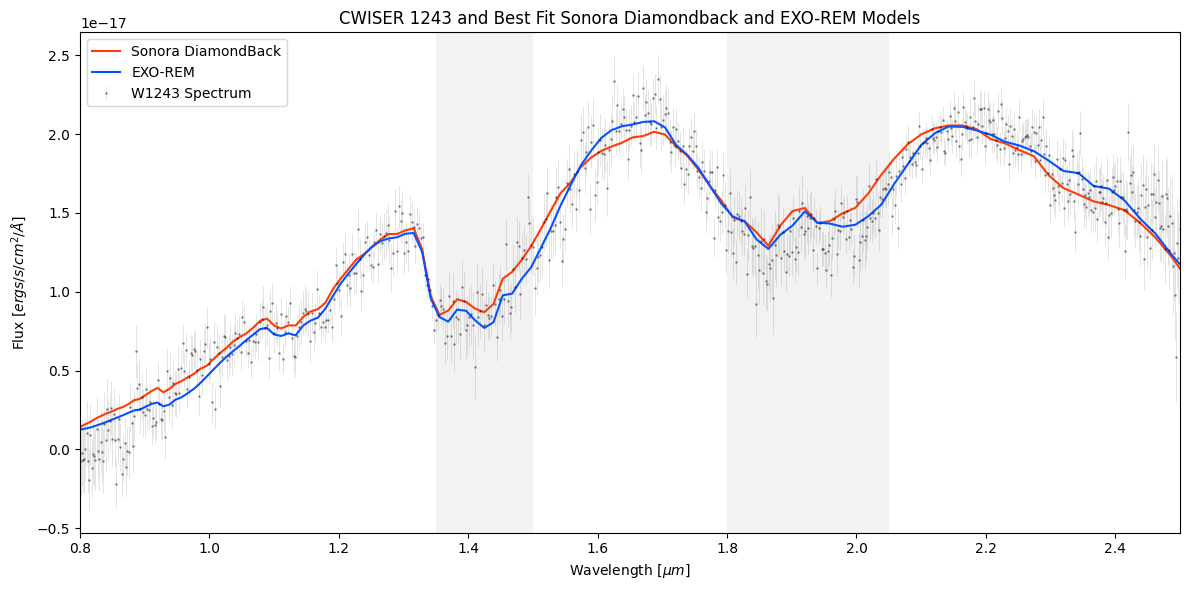

In [19]:
best_idx_sonora = sonora_db_df['chi2'].idxmin()
best_row_sonora = sonora_db_df.loc[best_idx_sonora]
best_model_path_sonora = best_row_sonora['file_path']
best_alpha_sonora = best_row_sonora['alpha']
best_chi2_sonora = best_row_sonora['chi2']

best_model_sonora = load_model_spectrum(best_model_path_sonora, skip_rows=3)
best_model_sonora = downbin_model(best_model_sonora, .8, 2.5)
flux_units_sonora = best_model_sonora.flux * u.W/u.m**2/u.m
flux_cgs_sonora = flux_units_sonora.to(u.erg/u.s/u.cm**2/u.AA)
best_model_sonora.flux = flux_cgs_sonora.value


best_idx_exorem = exorem_df['chi2'].idxmin()
best_row_exorem = exorem_df.loc[best_idx_exorem]
best_model_path_exorem = best_row_exorem['file_path']
best_alpha_exorem = best_row_exorem['alpha']
best_chi2_exorem = best_row_exorem['chi2']

best_model_exorem = load_model_spectrum(best_model_path_exorem, wavenumber = True, skip_rows=2)
best_model_exorem.wavelength = 10000.0 / best_model_exorem.wavenumber
best_model_exorem.flux = best_model_exorem.flux * (best_model_exorem.wavenumber**2) * 100
flux_units_exorem = best_model_exorem.flux * u.W/u.m**2/u.m
flux_cgs_exorem = flux_units_exorem.to(u.erg/u.s/u.cm**2/u.AA)
best_model_exorem.flux = flux_cgs_exorem.value

idx = np.argsort(best_model_exorem.wavelength)
best_model_exorem.wavelength = best_model_exorem.wavelength[idx]
best_model_exorem.flux = best_model_exorem.flux[idx]

best_model_exorem = downbin_model(best_model_exorem, 0.8, 2.5)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.errorbar(
    W1243_spectrum.wavelength,
    W1243_spectrum.flux,
    yerr=W1243_spectrum.error,
    fmt="o",
    ms=1,
    label='W1243 Spectrum',
    color='k',
    alpha=.3,
    ecolor='gray',
    elinewidth=.5
)

water_bands = [(1.35, 1.5), (1.8, 2.05)]
for start, end in water_bands:
    ax1.axvspan(start, end, color='grey', alpha=0.1, lw=0, zorder=0)

ax1.plot(
    best_model_sonora.wavelength,
    best_model_sonora.flux * best_alpha_sonora,
    label='Sonora DiamondBack',
    color='xkcd:red orange'
)

ax1.plot(
    best_model_exorem.wavelength,
    best_model_exorem.flux * best_alpha_exorem,
    label='EXO-REM',
    color='xkcd:electric blue'
)
       

ax1.set_title(rf"CWISER 1243 and Best Fit Sonora Diamondback and EXO-REM Models")
ax1.set_xlabel(r"Wavelength [$\mu m$]")
ax1.set_ylabel(r"Flux [$ergs/s/cm^2/\AA$]")
ax1.set_xlim(0.8, 2.5)
ax1.legend(loc='best')

plt.tight_layout()
plt.savefig(f"{plot_dir}/W1243_spectra_best_fit_sonora_exorem.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()